In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import joblib

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv('air_pollution_china.csv')

df = df.sort_values(by=['Year', 'Month', 'Hour']).reset_index(drop=True)

features = ['PM2.5 (µg/m³)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Pressure (hPa)']
data = df[features].fillna(method='ffill')

C:\Users\USER\AppData\Local\Temp\ipykernel_25136\4254549118.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = df[features].fillna(method='ffill')


In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

joblib.dump(scaler, 'models/scaler_polusi.pkl')

['models/scaler_polusi.pkl']

In [6]:
def create_sliding_window(dataset, time_steps=24):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:(i + time_steps), :])
        y.append(dataset[i + time_steps, 0])  
    return np.array(X), np.array(y)

time_steps = 24
X, y = create_sliding_window(scaled_data, time_steps)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [7]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)



Epoch 1/20

75/75 [==============================] - 5s 24ms/step - loss: 0.1018 - val_loss: 0.0781
Epoch 2/20
75/75 [==============================] - 1s 13ms/step - loss: 0.0846 - val_loss: 0.0788
Epoch 3/20
75/75 [==============================] - 1s 13ms/step - loss: 0.0848 - val_loss: 0.0822
Epoch 4/20
75/75 [==============================] - 1s 12ms/step - loss: 0.0844 - val_loss: 0.0778
Epoch 5/20
75/75 [==============================] - 1s 12ms/step - loss: 0.0835 - val_loss: 0.0792
Epoch 6/20
75/75 [==============================] - 1s 13ms/step - loss: 0.0844 - val_loss: 0.0784
Epoch 7/20
75/75 [==============================] - 1s 12ms/step - loss: 0.0833 - val_loss: 0.0793
Epoch 8/20
75/75 [==============================] - 1s 13ms/step - loss: 0.0823 - val_loss: 0.0799
Epoch 9/20
75/75 [==============================] - 1s 13ms/step - loss: 0.0830 - val_loss: 0.0780
Epoch 10/20
75/75 [==============================] - 1s 13ms/step - loss: 0.0838 - val_loss: 0.0775
Epoch 

In [8]:
model.save('models/model_polusi_lstm.h5')

c:\laragon\www\urban-ecosafe-project\.venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


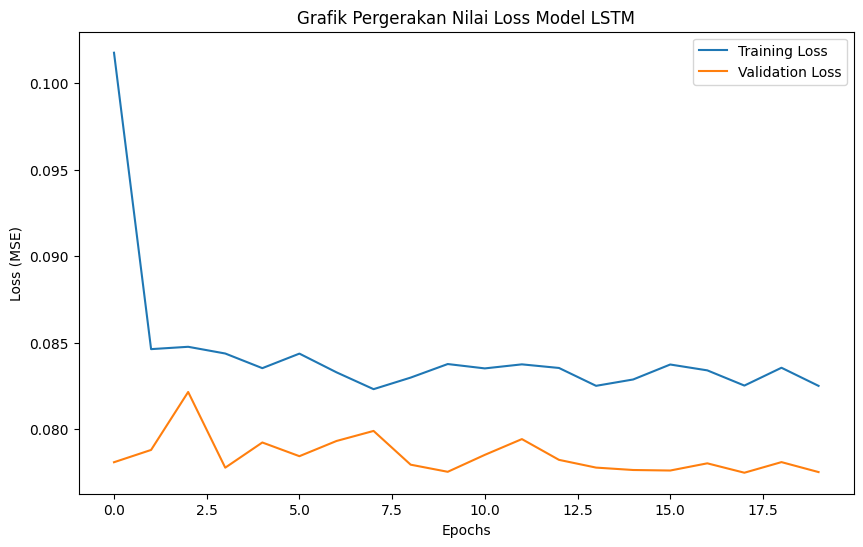

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Pergerakan Nilai Loss Model LSTM')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()